In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import fmatoolbox as fma
import ISRUtilities as isru
import pathlib
froot = pathlib.Path().cwd().parent.parent.parent / 'Results/Figures/ISIntervals'
batch_file = '/mnt/hubel-data-103/Pietro/InfraSlowNRPaper/Data/IS_intervals.batch'
do_save = False

In [2]:
def _loadISA(session,when=None):

    R = fma.regions.regions(session,phases=when,events='InfraSlowRhythm/infraslowaval',load_spikes=False)

    isa = {}; on = {}; cycles = {}; off = {}
    for r in np.intersect1d(['slownr','slowth'],list(R.events.keys())):
        reg = r[4:]
        isa[reg] = R.eventIntervals(r)
        on[reg] = R.eventIntervals(f'slowaval{reg}')
        cycles[reg], off[reg] = isru.ISCycles(isa[reg],on[reg],return_off=True)

    return isa, on, cycles, off, int(R.rat)

In [5]:
session = fma.data.readBatchFile(batch_file)[0][30]
print(session)
isa, on, cycles, off, rat = _loadISA(session)

/mnt/hubel-data-140/karadoc/Rat004_20240319/Rat004_20240319.xml


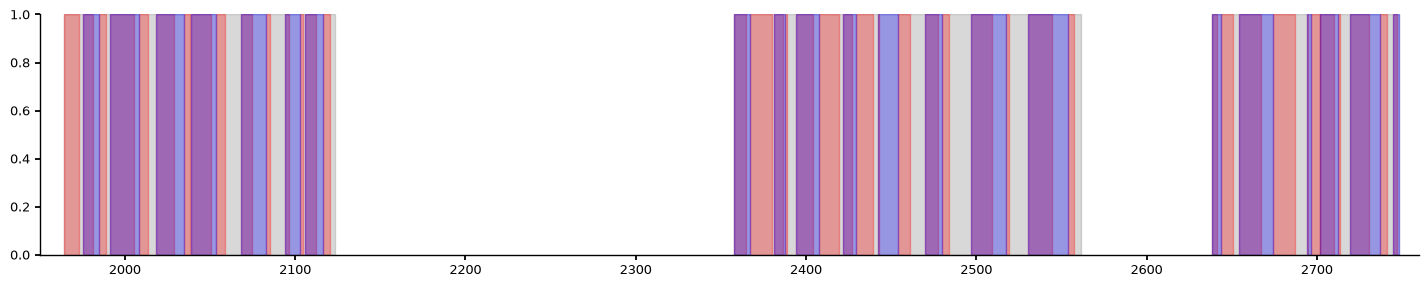

In [6]:
# check correctness of ISCycles()
_, ax = fma.plotting.makeFigure(size=[36,7])
fma.plotting.plotIntervals(isa['nr'])
fma.plotting.plotIntervals(on['nr'],color='r')
fma.plotting.plotIntervals(cycles['nr'][1::2,:],color='b')
ax[0].set_xlim(np.array([1950,2760])+0);

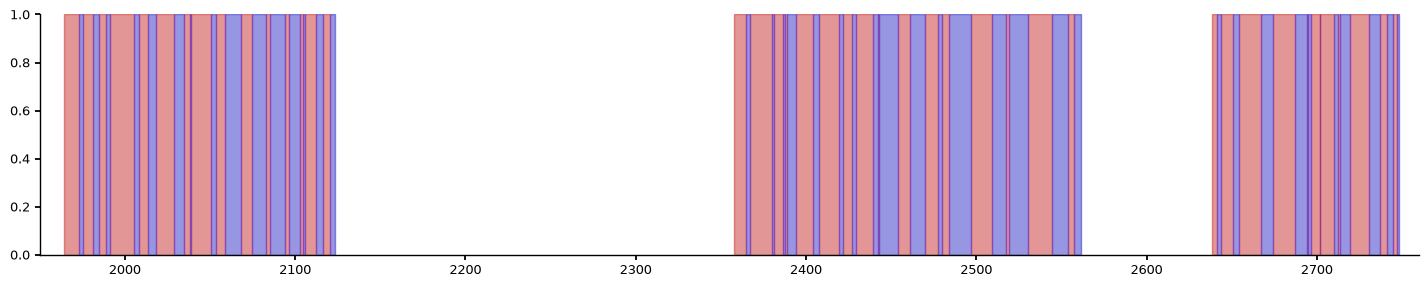

In [7]:
# check correctness of OFF intervals
_, ax = fma.plotting.makeFigure(size=[36,7])
fma.plotting.plotIntervals(isa['nr'])
fma.plotting.plotIntervals(on['nr'],color='r')
fma.plotting.plotIntervals(off['nr'][::,:],color='b')
ax[0].set_xlim(np.array([1950,2760])+0);

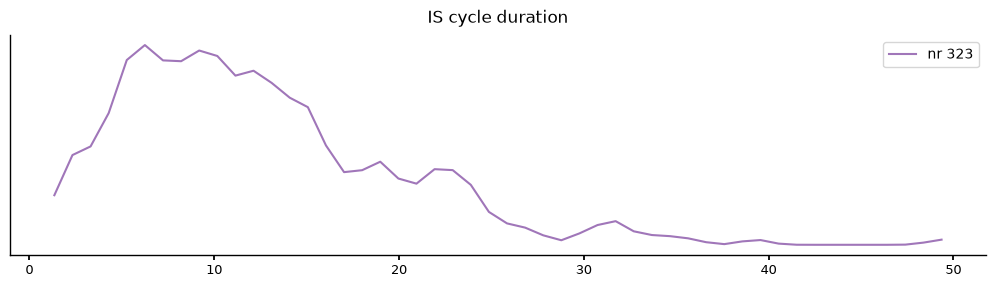

In [8]:
# higher max-avalanche duration, drop in tail separates two different states?
fig, ax = fma.plotting.makeFigure('IS cycle duration',size=[25,7])
for r in cycles:
    fma.plotting.plotPDF(np.diff(cycles[r]),bandwidth=.1,color=isru.paperColors(r),label=f'{r} {cycles[r].shape[0]}',ax=ax[0]);
ax[0].legend();

run batch

In [3]:
isa, on, cycles, off, rat = fma.data.runBatch(batch_file,_loadISA,kwargs={'when': 'sleep.*#0'},parallel=True)


Starting Batch, 2026-07-23 17:41:59.457623 

Batch completed with 0 errors, 2026-07-23 17:42:00.782961


In [4]:
# pool data
def poolData(x,rat,rat_unique):
    cat = {}
    for ra in rat_unique:
        cat[ra] = {}
        for reg in ['nr','th']:
            cat[ra][reg] = []
            for j, cycle in enumerate(x):
                if rat[j] == ra and reg in cycle:
                    cat[ra][reg].append(cycle[reg])
            if len(cat[ra][reg]):
                cat[ra][reg] = np.concatenate(cat[ra][reg],axis=0)
            else:
                cat[ra][reg] = np.zeros((0,2))
    return cat

In [5]:
rat_unique, rat_idx = np.unique(rat,return_inverse=True)
isa_cat = poolData(isa,rat,rat_unique)
on_cat = poolData(on,rat,rat_unique)
cycles_cat = poolData(cycles,rat,rat_unique)
off_cat = poolData(off,rat,rat_unique)

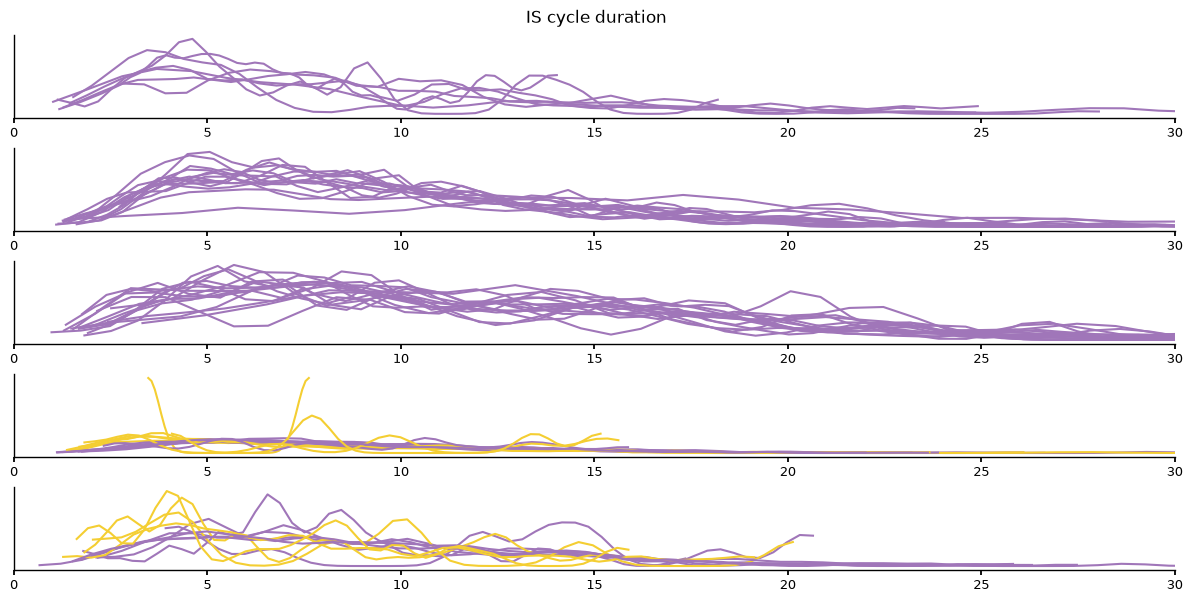

In [6]:
# per animal pdf
rat_unique, rat_idx = np.unique(rat,return_inverse=True)
fig, ax = fma.plotting.makeFigure('IS cycle duration',[len(rat_unique),1],size=[30,15])

for i, cycle in enumerate(cycles):
    for r in cycle:
        fma.plotting.plotPDF(np.diff(cycle[r]),bandwidth=.1,color=isru.paperColors(r),label=f'{r} {cycle[r].shape[0]}',ax=ax[rat_idx[i]])
fma.plotting.setProp(ax,xlim=[0,30])
#ax[0].legend();

main figures

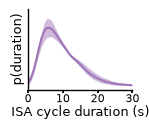

In [13]:
fig, ax = fma.plotting.makeFigure(size=(3.5,3))
alpha = 0.6
cycle = tuple(np.diff(cycles_cat[ra]['nr']) for i, ra in enumerate(cycles_cat))
x, y = fma.plotting.plotPDF(cycle,bins=np.linspace(0,30,40),color='none',ax=ax[0])
fma.plotting.semPlot(x[0],y,color=isru.paperColors('nr'),ax=ax[0])

ax[0].set(xlim=[0,30],xlabel='ISA cycle duration (s)')
ax[0].set_ylabel('p(duration)',labelpad=3)
do_save and fma.plotting.saveFigure(fig,froot / 'cycles',['png','svg'])

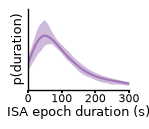

In [14]:
fig, ax = fma.plotting.makeFigure(size=(3.5,3))
alpha = 0.6
alpha_complement = 1 - alpha

cycle = tuple(np.diff(isa_cat[ra]['nr']) for i, ra in enumerate(isa_cat))
x, y = fma.plotting.plotPDF(cycle,bins=np.linspace(0,300,40),color='none',ax=ax[0])
fma.plotting.semPlot(x[0],y,color=isru.paperColors('nr'),ax=ax[0])

ax[0].set(xlim=[0,300],xlabel='ISA epoch duration (s)')
ax[0].set_ylabel('p(duration)',labelpad=3)
do_save and fma.plotting.saveFigure(fig,froot / 'epochs',['png','svg'])

supplementary figures

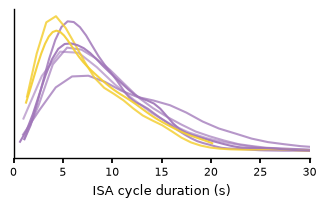

In [54]:
fig, ax = fma.plotting.makeFigure(size=[8,5])
alpha = 0.6
alpha_complement = 1 - alpha
for i, ra in enumerate(cycles_cat):
    for r, cycle in cycles_cat[ra].items():
        fma.plotting.plotPDF(np.diff(cycle),bandwidth=None,color=isru.paperColors(r),label=f'{r} {cycle.shape[0]}',ax=ax[0],alpha=alpha)
    alpha += alpha_complement / len(cycles_cat)
ax[0].set(xlim=[0,30],xlabel='ISA cycle duration (s)')
do_save and fma.plotting.saveFigure(fig,froot / 'nr_th_cycles',['png','svg'])

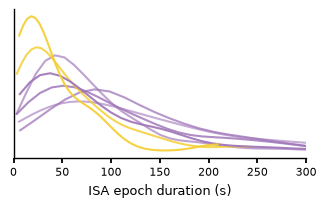

In [55]:
fig, ax = fma.plotting.makeFigure(size=[8,5])
alpha = 0.6
alpha_complement = 1 - alpha
for i, ra in enumerate(isa_cat):
    for r, cycle in isa_cat[ra].items():
        fma.plotting.plotPDF(np.diff(cycle),bandwidth=None,color=isru.paperColors(r),label=f'{r} {cycle.shape[0]}',ax=ax[0],alpha=alpha)
    alpha += alpha_complement / len(isa_cat)
ax[0].set(xlim=[0,300],xlabel='ISA epoch duration (s)')
do_save and fma.plotting.saveFigure(fig,froot / 'nr_th_epochs',['png','svg'])

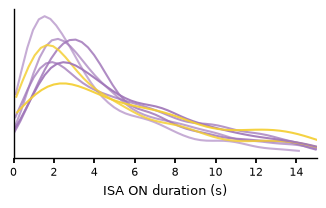

In [56]:
fig, ax = fma.plotting.makeFigure(size=[8,5])
alpha = 0.6
alpha_complement = 1 - alpha
for i, ra in enumerate(on_cat):
    for r, cycle in on_cat[ra].items():
        fma.plotting.plotPDF(np.diff(cycle),bandwidth=None,color=isru.paperColors(r),label=f'{r} {cycle.shape[0]}',ax=ax[0],alpha=alpha)
    alpha += alpha_complement / len(isa_cat)
ax[0].set(xlim=[0,15],xlabel='ISA ON duration (s)')
do_save and fma.plotting.saveFigure(fig,froot / 'nr_th_on',['png','svg'])

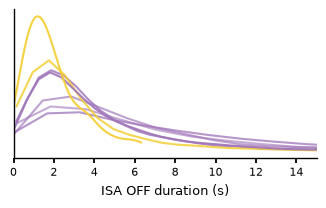

In [57]:
fig, ax = fma.plotting.makeFigure(size=[8,5])
alpha = 0.6
alpha_complement = 1 - alpha
for i, ra in enumerate(off_cat):
    for r, cycle in off_cat[ra].items():
        fma.plotting.plotPDF(np.diff(cycle),bandwidth=None,color=isru.paperColors(r),label=f'{r} {cycle.shape[0]}',ax=ax[0],alpha=alpha)
    alpha += alpha_complement / len(isa_cat)
fma.plotting.setProp(ax,xlim=[0,15])
ax[0].set(xlim=[0,15],xlabel='ISA OFF duration (s)')
do_save and fma.plotting.saveFigure(fig,froot / 'nr_th_off',['png','svg'])